In [34]:
## Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# Simulação / Carregamento do histórico de consultas e pagamentos da ClínicaCare
# Extração: Histórico operacional de pagamentos e consultas da ClínicaCare
dados_clinica = {
    'id_paciente': list(range(1, 41)),
    'tipo_plano': [
        'Unimed', 'Particular', 'Bradesco Saúde', 'Hapvida', 'Particular', 
        'Unimed', 'Amil', 'Bradesco Saúde', 'Particular', 'Unimed',
        'Hapvida', 'Particular', 'Amil', 'Bradesco Saúde', 'Unimed',
        'Particular', 'Unimed', 'Hapvida', 'Bradesco Saúde', 'Particular',
        'Amil', 'Unimed', 'Particular', 'Bradesco Saúde', 'Hapvida',
        'Particular', 'Unimed', 'Amil', 'Particular', 'Bradesco Saúde',
        'Unimed', 'Hapvida', 'Particular', 'Amil', 'Unimed',
        'Bradesco Saúde', 'Particular', 'Unimed', 'Hapvida', 'Particular'
    ],
    'valor_consulta': [
        300.00, 250.00, 280.00, 290.00, 300.00, 350.00, 270.00, 240.00, 320.00, 300.00,
        260.00, 310.00, 280.00, 300.00, 330.00, 250.00, 300.00, 270.00, 320.00, 400.00,
        280.00, 350.00, 250.00, 300.00, 290.00, 350.00, 300.00, 270.00, 310.00, 280.00,
        300.00, 260.00, 320.00, 280.00, 300.00, 290.00, 350.00, 300.00, 270.00, 400.00
    ],
    'dias_atraso': [
        0, 0, 0, 25, 0, 0, 35, 0, 0, 0,
        15, 0, 40, 0, 0, 5, 0, 18, 0, 45,
        30, 0, 2, 0, 22, 0, 0, 38, 0, 0,
        0, 19, 0, 28, 0, 0, 8, 0, 21, 50
    ],
    'numero_atrasos': [
        0, 0, 0, 3, 0, 0, 4, 0, 0, 0,
        2, 0, 5, 0, 0, 1, 0, 2, 0, 6,
        3, 0, 1, 0, 3, 0, 0, 4, 0, 0,
        0, 2, 0, 3, 0, 0, 1, 0, 3, 7
    ],
    'status_pagamento': [
        'Pago', 'Pago', 'Cancelado', 'Pendente', 'Pago', 
        'Pago', 'Pendente', 'Pago', 'Pago', 'Pago',
        'Pendente', 'Pago', 'Pendente', 'Pago', 'Pago',
        'Pago', 'Pago', 'Pendente', 'Pago', 'Pendente',
        'Pendente', 'Pago', 'Pago', 'Pago', 'Pendente',
        'Pago', 'Pago', 'Pendente', 'Pago', 'Pago',
        'Pago', 'Pendente', 'Pago', 'Pendente', 'Pago',
        'Pago', 'Pago', 'Pago', 'Pendente', 'Pendente'
    ]
}

df = pd.DataFrame(dados_clinica)
df.head()

,id_paciente,tipo_plano,valor_consulta,dias_atraso,numero_atrasos,status_pagamento
0,1,Unimed,300.0,0,0,Pago
1,2,Particular,250.0,0,0,Pago
2,3,Bradesco Saúde,280.0,0,0,Cancelado
3,4,Hapvida,290.0,25,3,Pendente
4,5,Particular,300.0,0,0,Pago


In [38]:
# Principais códigos para limpeza

# .head() -> Retorna as primeiras linhas do df
df.head(5)

# .tail() -> Retorna as ultimas linhas do df
df.tail(5)

# .info() -> Resumo do DataFrame
df.info()

# .describe() -> Retorna os dados estatísticos das colunas
df.describe()

# .value_counts() -> Retorna a quantidade de vezes que aparece uma linha (duplicatas)
df.value_counts()

# .isnull() -> Retorna valor booleano, se for true quer dizer que há valor nulo
df.isnull()

# .isnull().sum() -> Retorna quantidade de valores nulos
df.isnull().sum()

# .unique() -> Retorna valores únicos
df['tipo_plano'].unique()

# .isna() -> Retorna valores n/a
df.isna()

# .sum() -> Retorna a soma dos valores
df.sum()

# .sample() -> Retorna uma amostra aleatória
df.sample(5)

# .shape() -> Retorna a dimensão do DataFrame (linhas, colunas)
df.shape

# .columns -> Retorna as colunas do DataFrame
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_paciente       40 non-null     int64  
 1   tipo_plano        40 non-null     str    
 2   valor_consulta    40 non-null     float64
 3   dias_atraso       40 non-null     int64  
 4   numero_atrasos    40 non-null     int64  
 5   status_pagamento  40 non-null     str    
dtypes: float64(1), int64(3), str(2)
memory usage: 2.0 KB


Index(['id_paciente', 'tipo_plano', 'valor_consulta', 'dias_atraso',
       'numero_atrasos', 'status_pagamento'],
      dtype='str')

In [39]:
# Criação da feature

# Se o paciente nunca atrasou, a média é 0; caso contrário, dias_atraso / numero_atrasos
df['atraso_medio_pagamento'] = np.where(
    df['numero_atrasos'] > 0, 
    (df['dias_atraso'] / df['numero_atrasos']).round(2), 
    0.0
)

# Definição dos tipos
def definir_risco(linha):
    if linha['dias_atraso'] == 0 and linha['numero_atrasos'] == 0:
        return 'Baixo'
    elif linha['dias_atraso'] <= 20 or linha['numero_atrasos'] <= 2:
        return 'Médio'
    else:
        return 'Alto'

df['risco_inadimplencia'] = df.apply(definir_risco, axis=1)

# Contagem
print(df['risco_inadimplencia'].value_counts())
df.head()

risco_inadimplencia
Baixo    24
Alto     10
Médio     6
Name: count, dtype: int64


,id_paciente,tipo_plano,valor_consulta,dias_atraso,numero_atrasos,status_pagamento,atraso_medio_pagamento,risco_inadimplencia
0,1,Unimed,300.0,0,0,Pago,0.00,Baixo
1,2,Particular,250.0,0,0,Pago,0.00,Baixo
2,3,Bradesco Saúde,280.0,0,0,Cancelado,0.00,Baixo
3,4,Hapvida,290.0,25,3,Pendente,8.33,Alto
4,5,Particular,300.0,0,0,Pago,0.00,Baixo


In [40]:
# Análise descritiva
media_atraso = np.mean(df['dias_atraso'])
desvio_atraso = np.std(df['dias_atraso'])
mediana_atraso = np.median(df['dias_atraso'])
maximo_atraso = np.max(df['dias_atraso'])

print(f"Média de Atraso: {media_atraso:.2f} dias")
print(f"Desvio Padrão: {desvio_atraso:.2f} dias")
print(f"Mediana: {mediana_atraso:.2f} dias")
print(f"Maior Atraso Registrado:{maximo_atraso} dias")

Média de Atraso: 10.03 dias
Desvio Padrão: 15.01 dias
Mediana: 0.00 dias
Maior Atraso Registrado:50 dias


In [41]:
df.to_csv('clinica_care.csv', index=False)

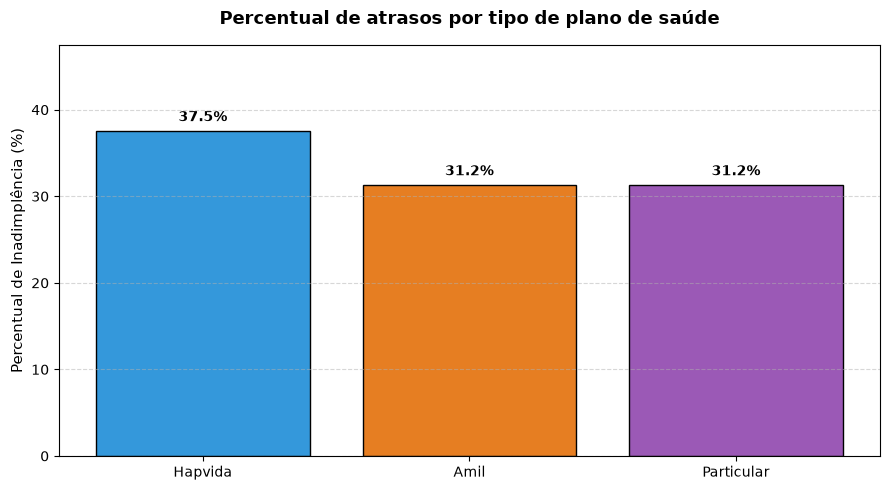

In [42]:
df_atrasos = df[df['dias_atraso'] > 0]

# Calculando o percentual de atrasos por plano de saúde
percentual_plano = (df_atrasos['tipo_plano'].value_counts(normalize=True) * 100).round(2)

cores_barras = ['#3498db', '#e67e22', '#9b59b6']

# Construção do Gráfico de Barras com Matplotlib
plt.figure(figsize=(9, 5))
barras = plt.bar(
    percentual_plano.index, 
    percentual_plano.values, 
    color=cores_barras, 
    edgecolor='black'
)

# Adicionando os rótulos nas barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2., 
        altura + 0.8,
        f'{altura:.1f}%', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

plt.title('Percentual de atrasos por tipo de plano de saúde', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Percentual de Inadimplência (%)', fontsize=11)
plt.ylim(0, percentual_plano.max() + 10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

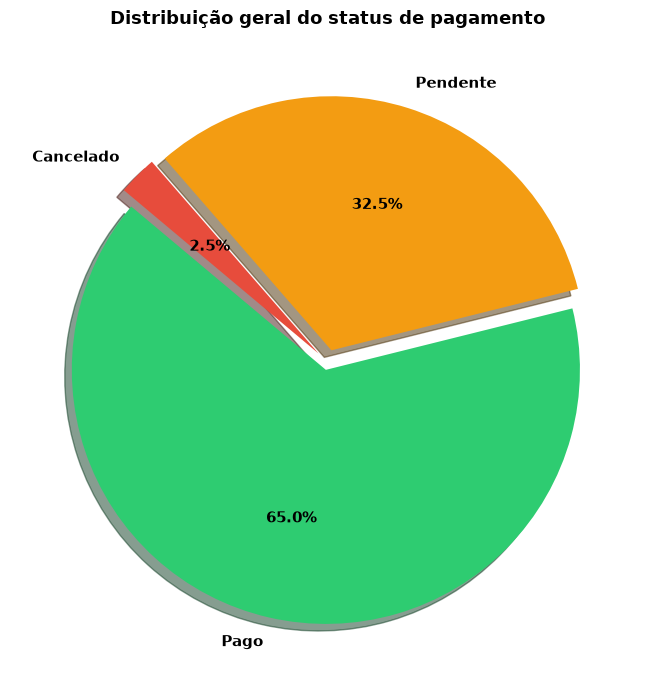

In [43]:
# 1. Contabilizando a distribuição dos status de pagamento
status_counts = df['status_pagamento'].value_counts()

# 2. Configurações de cores e destaque
cores = ['#2ecc71', '#f39c12', '#e74c3c']
destaque = (0.03, 0.05, 0.05)

# 3. Construção do Gráfico de Pizza com Matplotlib
plt.figure(figsize=(7, 7))
plt.pie(
    status_counts.values, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=cores, 
    explode=destaque,
    shadow=True,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title('Distribuição geral do status de pagamento', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [44]:
# Cópia do dataframe para salvar o dataset limpo
df_dados_limpos = df.copy()

# Exportando o arquivo limpo
df_dados_limpos.to_csv('dados_limpos.csv', index=False)

In [45]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve)

In [46]:
# Separando as features e o target
X = df[['dias_atraso', 'numero_atrasos', 'valor_consulta']]
y = df['risco_inadimplencia']

# Exibir informações básicas sobre nosso dataset
print("VISÃO GERAL DO DATASET")
print(f"Formato do dataset (Features): {X.shape}")
print(f"Formato do target: {y.shape}")

print("\nPRIMEIRAS 5 LINHAS (FEATURES)")
print(X.head())

print("\nRESUMO ESTATÍSTICO")
print(X.describe())

print("\nTIPOS DE DADOS E VALORES AUSENTES")
print(X.info())
print(f"\nValores ausentes nas features: {X.isnull().sum().sum()}")
print(f"Valores ausentes no target: {pd.isnull(y).sum()}")

print("\nINFORMAÇÕES SOBRE O TARGET (RISCO DE INADIMPLÊNCIA)")
print(f"Classes identificadas: {np.unique(y)}")
print("Contagem por nível de risco:")
unique, counts = np.unique(y, return_counts=True)
for class_val, count in zip(unique, counts):
    percentual = (count / len(y)) * 100
    print(f"  - Risco {class_val}: {count} pacientes ({percentual:.1f}%)")

VISÃO GERAL DO DATASET
Formato do dataset (Features): (40, 3)
Formato do target: (40,)

PRIMEIRAS 5 LINHAS (FEATURES)
   dias_atraso  numero_atrasos  valor_consulta
0            0               0           300.0
1            0               0           250.0
2            0               0           280.0
3           25               3           290.0
4            0               0           300.0

RESUMO ESTATÍSTICO
       dias_atraso  numero_atrasos  valor_consulta
count     40.00000       40.000000       40.000000
mean      10.02500        1.250000      299.250000
std       15.20035        1.891276       36.682106
min        0.00000        0.000000      240.000000
25%        0.00000        0.000000      277.500000
50%        0.00000        0.000000      300.000000
75%       19.50000        2.250000      312.500000
max       50.00000        7.000000      400.000000

TIPOS DE DADOS E VALORES AUSENTES
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 colum

FEATURES (X)
Formato das features: (40, 3)
Nomes das features: ['dias_atraso', 'numero_atrasos', 'valor_consulta']
Tipos das features: [dtype('int64') dtype('float64')]

TARGET (y)
Formato do target: (40,)
Tipo do target: <class 'pandas.Series'>
Valores únicos do target:['Alto' 'Baixo' 'Médio']
Target representa: ['Alto', 'Baixo', 'Médio']

ANÁLISE DAS FEATURES
Analisando as 3 features preditoras


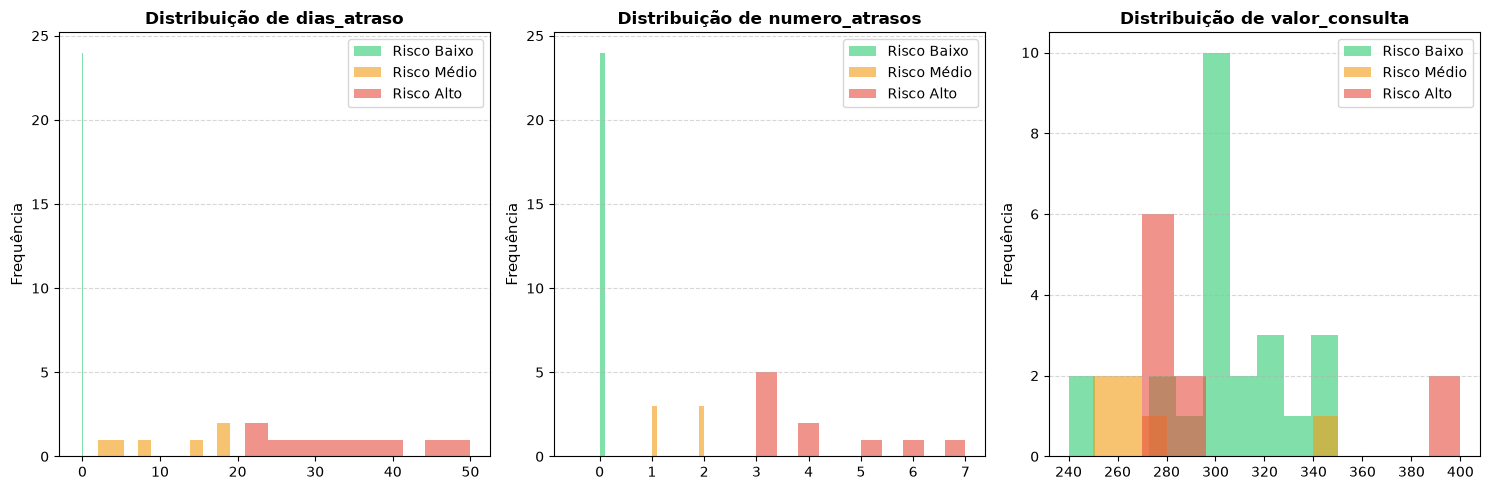

In [47]:
print("FEATURES (X)")
print(f"Formato das features: {X.shape}")
print(f"Nomes das features: {list(X.columns)}")
print(f"Tipos das features: {X.dtypes.unique()}")

print("\nTARGET (y)")
print(f"Formato do target: {y.shape}")
print(f"Tipo do target: {type(y)}")
print(f"Valores únicos do target:{np.unique(y)}")
print("Target representa: ['Alto', 'Baixo', 'Médio']")

# Lista com as 3 features do modelo
main_features = list(X.columns)
print(f"\nANÁLISE DAS FEATURES")
print(f"Analisando as {len(main_features)} features preditoras")

# Configuração dos histogramas por classe
plt.figure(figsize=(15, 5))
for i, feature in enumerate(main_features):
    plt.subplot(1, 3, i + 1)

    dados_baixo = X[y == 'Baixo'][feature]
    dados_medio = X[y == 'Médio'][feature]
    dados_alto  = X[y == 'Alto'][feature]

    plt.hist(dados_baixo, alpha=0.6, label='Risco Baixo', bins=10, color='#2ecc71')
    plt.hist(dados_medio, alpha=0.6, label='Risco Médio', bins=10, color='#f39c12')
    plt.hist(dados_alto,  alpha=0.6, label='Risco Alto',  bins=10, color='#e74c3c')

    plt.ylabel('Frequência', fontsize=11)
    plt.title(f'Distribuição de {feature}', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [48]:
# Divisão estratificada em 75% para treinamento e 25% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

print(f"Total de amostras para Treino: {X_train.shape[0]}")
print(f"Total de amostras para Teste: {X_test.shape[0]}")

Total de amostras para Treino: 30
Total de amostras para Teste: 10


In [49]:
# Padronização das escalas das features (média 0 e desvio padrão 1)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
# Instanciação e treinamento do classificador de Regressão Logística
modelo_logistico = LogisticRegression(random_state=42, max_iter=1000)
modelo_logistico.fit(X_train_scaled, y_train)

# Predição no conjunto de teste
y_pred = modelo_logistico.predict(X_test_scaled)

In [53]:
# Cálculo das métricas fundamentais de classificação
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall   = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1       = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("MÉTRICAS DE AVALIAÇÃO DO MODELO")
print(f"Acurácia: {acuracia * 100:.2f}%")
print(f"Precisão: {precisao:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

MÉTRICAS DE AVALIAÇÃO DO MODELO
Acurácia: 90.00%
Precisão: 0.81
Recall: 0.90
F1-Score: 0.85


In [54]:
print("\nRelatório Detalhado de Classificação")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de Confusão
matriz = confusion_matrix(y_test, y_pred, labels=['Baixo', 'Médio', 'Alto'])
print("Matriz de Confusão")
print("Linhas: Real | Colunas: Previsto [Baixo, Médio, Alto]")
print(matriz)


Relatório Detalhado de Classificação
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00         3
       Baixo       0.86      1.00      0.92         6
       Médio       0.00      0.00      0.00         1

    accuracy                           0.90        10
   macro avg       0.62      0.67      0.64        10
weighted avg       0.81      0.90      0.85        10

Matriz de Confusão
Linhas: Real | Colunas: Previsto [Baixo, Médio, Alto]
[[6 0 0]
 [1 0 0]
 [0 0 3]]
